<a href="https://colab.research.google.com/github/Tejomayi06/HPC-PROJECT/blob/main/hpcproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gcc --version

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [ ]:
%%writefile matmul_openmp.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 500  // Matrix size

int main() {
    int i, j, k;
    static double A[N][N], B[N][N], C[N][N];

    // Initialize matrices
    for(i = 0; i < N; i++)
        for(j = 0; j < N; j++) {
            A[i][j] = i + j;
            B[i][j] = i - j;
            C[i][j] = 0;
        }

    double start = omp_get_wtime();

    // Parallel Matrix Multiplication
    #pragma omp parallel for private(i, j, k) shared(A, B, C)
    for(i = 0; i < N; i++) {
        for(j = 0; j < N; j++) {
            for(k = 0; k < N; k++) {
                C[i][j] += A[i][k] * B[k][j];
            }
        }
    }

    double end = omp_get_wtime();

    printf("Time taken: %f seconds\n", end - start);

    return 0;
}

Overwriting matmul_openmp.c


In [ ]:
!gcc -fopenmp matmul_openmp.c -o matmul

In [ ]:
import os
import subprocess

threads = [1, 2, 4, 8]
times = []

for t in threads:
    os.environ["OMP_NUM_THREADS"] = str(t)
    result = subprocess.getoutput("./matmul")
    print(f"Threads={t} -> {result}")

    time_taken = float(result.split()[-2])
    times.append(time_taken)

Threads=1 -> Time taken: 0.481000 seconds
Threads=2 -> Time taken: 0.361581 seconds
Threads=4 -> Time taken: 0.373183 seconds
Threads=8 -> Time taken: 0.362569 seconds


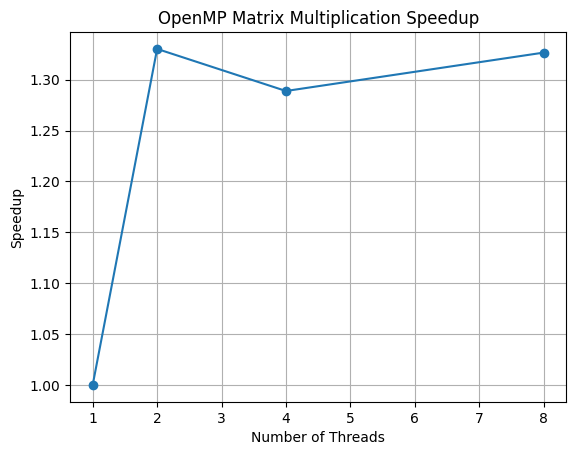

In [ ]:
import matplotlib.pyplot as plt

threads = [1, 2, 4, 8]
times = times

# Calculate speedup
speedup = [times[0]/t for t in times]

plt.figure()
plt.plot(threads, speedup, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Speedup")
plt.title("OpenMP Matrix Multiplication Speedup")
plt.grid()

plt.show()

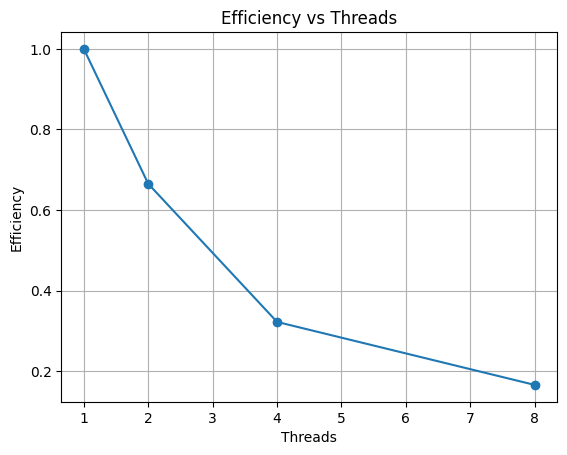

In [ ]:
efficiency = [speedup[i]/threads[i] for i in range(len(threads))]

plt.figure()
plt.plot(threads, efficiency, marker='o')
plt.xlabel("Threads")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Threads")
plt.grid()

plt.show()